<a href="https://colab.research.google.com/github/eman-alsayed-hasan/DATATSC-ENCE-ECOSYSTEM/blob/main/part2_paris_prompts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# We need to install the following packages to run the code in this notebook
# %%capture
!pip install datasets
!pip install openai
!pip install -U llama-index llama-index-readers-file llama-index-embeddings-openai pymupdf # ATTENTION: You may need to restart the session to load these successfully

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.1/378.1 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Succes

In [1]:
import openai
from openai import OpenAI
import json
from huggingface_hub import hf_hub_download
from datasets import load_dataset

In [2]:
# This here is how we will load the SDG dataset from the HuggingFace Hub.
# It has already been preprocessed for you to use.
dataset = load_dataset("dspoka/sdg-single")

# Here we will transform the dataset into a pandas dataframe
df_full = dataset['full'].to_pandas()

print(f'The dataset has {df_full.shape[0]} rows and {df_full.shape[1]} columns')
print(f'The columns are: {df_full.columns.values}')
df_full.head()

README.md:   0%|          | 0.00/777 [00:00<?, ?B/s]

data/full-00000-of-00001-c9b480cdebf4ea5(…): reconstructing file:   0%|          |  0.00B /  810kB            

data/full-00000-of-00001-c9b480cdebf4ea5(…): downloading bytes:           |  0.00B            

Generating full split:   0%|          | 0/14219 [00:00<?, ? examples/s]

The dataset has 14219 rows and 13 columns
The columns are: ['iso3' 'country' 'goal' 'target' 'text' 'status' 'sector' 'response'
 'infotype' 'start' 'end' 'filename' '__index_level_0__']


,iso3,country,goal,target,text,status,sector,response,infotype,start,end,filename,__index_level_0__
0,AFG,Afghanistan,12,12.2,Reduce rural peoples’ dependence on fuel for c...,future,energy efficiency,mitigation,needs_and_gaps,28031.0,28096.0,AFG-first_ndc-EN.html,0
1,AFG,Afghanistan,1,1.5,Reducing vulnerability of the country and its ...,future,health,adaptation,action,12482.0,12648.0,AFG-first_ndc-EN.html,1
2,AFG,Afghanistan,13,13.1,Reducing vulnerability of the country and its ...,future,health,adaptation,action,12482.0,12648.0,AFG-first_ndc-EN.html,2
3,AFG,Afghanistan,15,15.2,Regeneration of at least 40% of existing degra...,not_specified,not_specified,not_specified,not_specified,19765.0,19906.0,AFG-first_ndc-EN.html,3
4,AFG,Afghanistan,7,7.2,"Renewable energy, entry costs support, access ...",future,renewable energy,mitigation,needs_and_gaps,27461.0,27532.0,AFG-first_ndc-EN.html,4


In [3]:
def unpack_and_explain_metadata(metadata):
    '''Args:
        metadata: dictionary containing the metadata for the dataset.
    Returns:
        goal_idx_2_description: dictionary mapping goal index to the text description of the goal.
        goal_idx_2_goal_number: dictionary mapping goal index to the goal number. The goal number is what is currently in the dataset frame.
        target_idx_2_description: dictionary mapping target index to the text description of the target.
        target_idx_2_goal_idx: dictionary that maps a target index to the goal index. There are multiple targets per goal.
        target_idx_2_target_number: dictionary that maps a target index to the target number. The target number is what is currently in the dataset frame.

    '''
    goal_idx_2_description = metadata['goal_idx_2_description']
    goal_idx_2_description = {int(k):v for k,v in goal_idx_2_description.items()}

    goal_idx_2_goal_number = metadata['goal_idx_2_goal_number']
    goal_idx_2_goal_number = {int(k):v for k,v in goal_idx_2_goal_number.items()}

    target_idx_2_description = metadata['target_idx_2_description']
    target_idx_2_description = {int(k):v for k,v in target_idx_2_description.items()}

    target_idx_2_goal_idx = metadata['target_idx_2_goal_idx']
    target_idx_2_goal_idx = {int(k):int(v) for k,v in target_idx_2_goal_idx.items()}

    target_idx_2_target_number = metadata['target_idx_2_target_number']
    target_idx_2_target_number = {int(k):v for k,v in target_idx_2_target_number.items()}

    return goal_idx_2_description, goal_idx_2_goal_number, target_idx_2_description, target_idx_2_goal_idx, target_idx_2_target_number


# We will also download the metadata for the dataset from the HuggingFace Hub.
filepath = hf_hub_download(repo_id="dspoka/sdg-single", filename="metadata.json", repo_type="dataset")
with open(filepath) as f:
    metadata = json.load(f)

# In this method we will unpack the dictionaries and explain what each of the metadata means
goal_idx_2_description, goal_idx_2_goal_number, target_idx_2_description, target_idx_2_goal_idx, target_idx_2_target_number = unpack_and_explain_metadata(metadata)

metadata.json:   0%|          | 0.00/33.4k [00:00<?, ?B/s]

In [4]:
# first row
print(df_full.iloc[0])
# and here is the text of the first row:
print('Text', df_full.iloc[0]['text'])

iso3                                                               AFG
country                                                    Afghanistan
goal                                                                12
target                                                            12.2
text                 Reduce rural peoples’ dependence on fuel for c...
status                                                          future
sector                                               energy efficiency
response                                                    mitigation
infotype                                                needs_and_gaps
start                                                          28031.0
end                                                            28096.0
filename                                         AFG-first_ndc-EN.html
__index_level_0__                                                    0
Name: 0, dtype: object
Text Reduce rural peoples’ dependence on fuel for cook

In [5]:
goal_number = "12"
goal_idx = None
for k,v in goal_idx_2_goal_number.items():
    if v == "12":
        goal_idx = k
        break

print(f'There are {len(goal_idx_2_description)} goals in the dataset.')
print(f'The "{goal_number}" goal has this text description: {goal_idx_2_description[goal_idx]}')

There are 17 goals in the dataset.
The "12" goal has this text description:  Ensure sustainable consumption and production patterns


In [6]:
# Find all target_ids that belong to goal 0
target_ids = []
for target_id, goal_id in target_idx_2_goal_idx.items():
    if goal_id == goal_idx:
        target_ids.append(target_id)

# And now lets print all the descriptions of the targets that belong to goal 0
for target_id in target_ids:
    print(f'Target {target_id} has the following description: {target_idx_2_description[target_id]}')

Target 0 has the following description: By 2030, achieve the sustainable management and efficient use of natural resources
Target 9 has the following description: By 2030, substantially reduce waste generation through prevention, reduction, recycling and reuse
Target 20 has the following description: Implement the 10-year framework of programmes on sustainable consumption and production, all countries taking action, with developed countries taking the lead, taking into account the development and capabilities of developing countries
Target 21 has the following description: By 2020, achieve the environmentally sound management of chemicals and all wastes throughout their life cycle, in accordance with agreed international frameworks, and significantly reduce their release to air, water and soil in order to minimize their adverse impacts on human health and the environment
Target 29 has the following description: By 2030, ensure that people everywhere have the relevant information and aw

<Axes: xlabel='goal'>

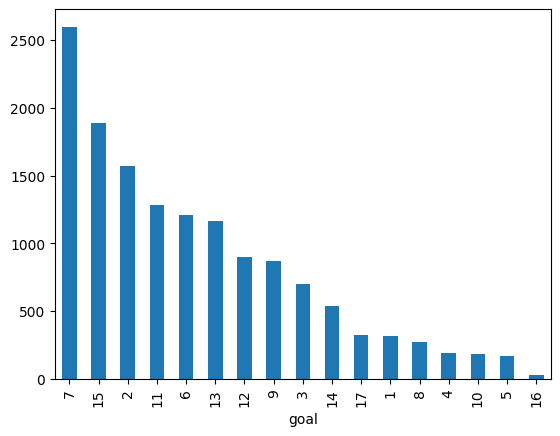

In [7]:
# Lets also plot the histogram of goals in the dataset
df_full['goal'].value_counts().plot(kind='bar')

In [8]:
import os
import pandas as pd
import numpy as np
import random

# set seeds for reproducibility
np.random.seed(42)
random.seed(42)


# lets setup some global variables

# for goal prediction this will be the number of classes
N_PRED_CLASSES = len(goal_idx_2_goal_number)
# this will signify to the model the start of the input text
INPUT_MARKER = 'Input Text'

# This dictionary just contains the names of the columns to slightly longer names that are easier to understand.
column_names = {'goal': 'Sustainable Development Goal', 'target': 'Subgoal', 'status': 'Status', 'sector': 'Sector', 'response': 'Climate Response', 'infotype': 'Information Type'}

In [9]:
# for now we will skip the special_token as well as the what the "context" column is.
def build_instruction(pred_column, obs_column):
    ''' Args:
            pred_column (str): the column that we are predicting
            obs_column (str): the column that we are observing (e.g. text, context)
        Returns:
            prompt (str): the prompt that will be used to query the model

    '''
    # describe what the model's input, task and class options are.
    prompt = f'You are provided with an input text **{INPUT_MARKER}**. Your task is to predict the {column_names[pred_column]} ({pred_column}) out of the following {N_PRED_CLASSES} options:\n'

    # for now we will assume that we are predicting the goal column
    assert pred_column == 'goal'
    goal_number_2_goal_idx = {v: k for k, v in goal_idx_2_goal_number.items()}

    # Here we are building a dictionary that maps the goal number to the goal description
    goal_number_2_goal_description = {k:goal_idx_2_description[v] for k, v in goal_number_2_goal_idx.items()}

    # we sort this according to the goal number
    sorted_keys = sorted(int(k) for k in list(goal_number_2_goal_description.keys()))
    sorted_keys = [str(k) for k in sorted_keys]

    # build a list of strings where each string is the goal number and the goal description
    values = [f'{key}:{goal_number_2_goal_description[key]}' for key in sorted_keys]
    name = column_names[pred_column]
    # and we join each goal/description with a new line to the intruction
    prompt += name + '\n' +"\n".join(values) + "\n\n"
    return prompt

In [10]:
# Create an example
prompt_example = build_instruction(pred_column='goal', obs_column='text')
print(prompt_example)

You are provided with an input text **Input Text**. Your task is to predict the Sustainable Development Goal (goal) out of the following 17 options:
Sustainable Development Goal
1: End poverty in all its forms everywhere
2: End hunger, achieve food security and improved nutrition and promote sustainable agriculture
3: Ensure healthy lives and promote well-being for all at all ages
4: Ensure inclusive and equitable quality education and promote lifelong learning opportunities for all
5: Achieve gender equality and empower all women and girls
6: Ensure availability and sustainable management of water and sanitation for all
7: Ensure access to affordable, reliable, sustainable and modern energy for all
8: Promote sustained, inclusive and sustainable economic growth, full and productive employment and decent work for all
9: Build resilient infrastructure, promote inclusive and sustainable industrialization and foster innovation
10: Reduce inequality within and among countries
11: Make citi

In [11]:
def build_single_prompt(row, pred_column, obs_column, test_input_only=False):
    ''' Args:
        row (pd.Series): a row from the dataframe
        obs_column (str): the column that we are observing (e.g. text, context)
        test_input_only (bool):
            - if True, only return the input text
                - This is used for the test example.
            - if False, return the input text and the correct answer
                - This will be for in-context learning
        Returns:
            prompt (str): the second portion of the prompt
    '''
    prompt = f'\n**{INPUT_MARKER}**: {row[obs_column]}\n'
    if test_input_only:
        return prompt

    value = row[pred_column]
    prompt += f'{pred_column}:{value}\n'
    prompt += '\n'
    return prompt

In [12]:
# Create an example
prompt_example = build_instruction(pred_column='goal', obs_column='text')

# Sample a random row from the dataframe to use as a test example
random_test_row = df_full.sample(1).iloc[0]
test_input = build_single_prompt(random_test_row, pred_column='goal', obs_column='text', test_input_only=True)

prompt_example += "Given these categories, please classify the following **Input Text** by only answering with the single number of the goal:"
prompt_example += test_input
prompt_example += f'goal:'
# Here we have the full instruction and prompt for the model
print(prompt_example)

You are provided with an input text **Input Text**. Your task is to predict the Sustainable Development Goal (goal) out of the following 17 options:
Sustainable Development Goal
1: End poverty in all its forms everywhere
2: End hunger, achieve food security and improved nutrition and promote sustainable agriculture
3: Ensure healthy lives and promote well-being for all at all ages
4: Ensure inclusive and equitable quality education and promote lifelong learning opportunities for all
5: Achieve gender equality and empower all women and girls
6: Ensure availability and sustainable management of water and sanitation for all
7: Ensure access to affordable, reliable, sustainable and modern energy for all
8: Promote sustained, inclusive and sustainable economic growth, full and productive employment and decent work for all
9: Build resilient infrastructure, promote inclusive and sustainable industrialization and foster innovation
10: Reduce inequality within and among countries
11: Make citi

In [13]:
# To use the model, you will need to sign up for an OpenAI Account (http://platform.openai.com/signup) and get an API key pasted below.
# so we will use this particular model
API_KEY="sk-"
MODEL_NAME = "gpt-4o-mini-2024-07-18"
CLIENT = OpenAI(api_key=API_KEY)

def get_model_response(CLIENT, MODEL, prompt):
  completion = CLIENT.chat.completions.create(
    model=MODEL,
    messages=[
      {"role": "user", "content": prompt}
    ],
    temperature=0
  )

  return completion.choices[0].message.content

In [15]:
from sklearn.model_selection import train_test_split

def make_new_splits(df):
    '''We want to make sure that we split into train/val/test by documents and not by sentences. This helps us ensure that we aren't overfitting to a particular document/country.
    Suppose (hyperbolically) that each document only had one SDG class. Then if we split by sentence, the model may overfit by first predicting which country the sentence is from, and then predicting the SDG goal based on that country. This is undesirable and so it is better to split by documents.
    Args:
        df (pd.DataFrame): the full dataframe
    Returns:
        df_train (pd.DataFrame): the training dataframe
        df_val (pd.DataFrame): the validation dataframe
        df_test (pd.DataFrame): the test dataframe
    '''
    seed = 42
    filenames = df['filename'].unique()
    train_filenames, test_filenames = train_test_split(filenames, test_size=0.4, random_state=seed)
    val_filenames, test_filenames = train_test_split(test_filenames, test_size=0.5, random_state=seed)
    print(len(train_filenames), len(val_filenames), len(test_filenames))
    df_train = df[df['filename'].isin(train_filenames)]
    df_val = df[df['filename'].isin(val_filenames)]
    df_test = df[df['filename'].isin(test_filenames)]
    print(f'train: {df_train.shape}\tval: {df_val.shape}\ttest: {df_test.shape}')
    return df_train, df_val, df_test

In [16]:
df_train, df_val, df_test = make_new_splits(df_full)

128 43 43
train: (9611, 13)	val: (2507, 13)	test: (2101, 13)


In [17]:
def in_context_prompt(df, pred_column, obs_column, num_samples=3):
    '''
        Args:
            df (pd.DataFrame): the dataframe that we are sampling from
            pred_column (str): the column that we are predicting
            obs_column (str): the column that we are observing
            num_samples (int): the number of in-context learning samples to add to the prompt
        Returns:
            prompt (str): the full prompt for the model
    '''
    # as before we build the instruction
    prompt = build_instruction(pred_column, obs_column)

    # for each icl example we sample a random row from the dataframe
    prompt += "\nYou are also provided with the following examples of classifications:\n[BEGIN OF EXAMPLES]\n"
    for i in range(num_samples):
        row = df.sample(1)
        # note that we set test_input_only to false since we want to include the goal label for the icl examples
        prompt += build_single_prompt(row.iloc[0], pred_column, obs_column, test_input_only=False)
    prompt += "[END OF EXAMPLES]\n"
    return prompt

In [18]:
# We need to split df_full into train/val such that the ICL examples dont overlap with the test example
# df_train = df_full.sample(frac=0.8, random_state=42)
# df_val = df_full.drop(df_train.index)

icl_prompt_example = in_context_prompt(df_train, pred_column='goal', obs_column='text', num_samples=5)

# sample a random row from the dataframe to use as a test example
random_test_row = df_val.sample(1).iloc[0]
test_input = build_single_prompt(random_test_row, pred_column='goal', obs_column='text', test_input_only=True)

icl_prompt_example += "\nGiven these categories and examples, please classify the following **Input Text**  by only answering with the single number of the goal:"
icl_prompt_example += test_input
icl_prompt_example += f'{"goal"}:'
print(icl_prompt_example)
print('-'*80)
print('True Goal', random_test_row['goal'])

You are provided with an input text **Input Text**. Your task is to predict the Sustainable Development Goal (goal) out of the following 17 options:
Sustainable Development Goal
1: End poverty in all its forms everywhere
2: End hunger, achieve food security and improved nutrition and promote sustainable agriculture
3: Ensure healthy lives and promote well-being for all at all ages
4: Ensure inclusive and equitable quality education and promote lifelong learning opportunities for all
5: Achieve gender equality and empower all women and girls
6: Ensure availability and sustainable management of water and sanitation for all
7: Ensure access to affordable, reliable, sustainable and modern energy for all
8: Promote sustained, inclusive and sustainable economic growth, full and productive employment and decent work for all
9: Build resilient infrastructure, promote inclusive and sustainable industrialization and foster innovation
10: Reduce inequality within and among countries
11: Make citi

In [19]:
def calculate_accuracy(true_, pred_):
    ''' Calculate accuracy of predictions
        There could be multiple true labels for each example
        There is only one predicted label for each example
        Args:
            true_ (list): list of lists of true labels
            pred_ (list): list of predicted labels
        Returns:
            accuracy (float): the accuracy of the predictions
    '''
    assert len(true_) == len(pred_)
    # accuracy = sum([t==p for t, p in zip(true_, pred_)])/len(true_) # this is when there is only one true label
    right = 0
    for t, p in zip(true_, pred_):
        assert type(t) == list
        if p in t:
            right += 1
    return right/len(true_)

def most_common(lst):
    ''' helper function to select the most common element in a list
        Args:
            lst: list of elements
        Returns:
            most common element in the list
    '''
    # print('lst', lst)
    # print('type(lst)', type(lst)
    if type(lst) == str:
        return lst
    return max(set(lst), key=lst.count)

In [20]:
def run_eval(df_train, df_test, pred_column, obs_column, num_samples, num_icl, CLIENT, MODEL):
    '''
        Args:
            df_train (pd.DataFrame): the dataframe that we are sampling from for ICL examples
            df_test (pd.DataFrame): the dataframe that we are sampling from for test examples
            pred_column (str): the column name that we are predicting
            obs_column (str): the column name that we are observing
            num_samples (int): the number of test examples to evaluate on
            num_icl (int): the number of in-context learning examples to include in the prompt
            CLIENT (str): OpenAI model client
            MODEL (str): used OpenAI model
        Returns:
        true_ (list): list of lists of true labels
        pred_ (list): list of predicted labels
        test_texts (list): list of the test examples
        test_prompt (str): the full last prompt used for the model for debugging/sanity check purposes
        test_ids (list): list of the ids of the test examples (this is useful such that the same test examples are not labeled multiple times)


    '''
    # Note if we set the test_prompt outside the for loop here
    # Then are using the same ICL prompt for all test examples.
    # If we do so, we can then more easily get batch predictions from the API
    # However, if we sample unlucky ICL examples, then the model may not perform as well.
    # So we will leave it inside the for loop for now.
    # test_prompt = in_context_prompt(df_train, pred_column, obs_column, num_icl)
    ################################################################################

    # Recall that one piece of text has many goals and targets.
    # So in our dataframe there multiple rows which have the same text.
    # This line to group makes sure that only unique texts are present.
    # It also aggregates the multiple goals for the same text into a list.
    df_group = df_test.groupby(obs_column, as_index=False).agg(lambda x: list(x))

    ######## Another strategy would be to use majority SDG goal
    # assert df_group[pred_column].apply(lambda x: type(x) == list).all()
    # df_group['majority'] = df_group[pred_column].apply(lambda x: most_common(x))
    ################################################################################


    # make sure that the text column is a list and only has one unique element
    if obs_column != 'text':
        assert df_group['text'].apply(lambda x: len(set(x)) == 1).all()
        df_group['text'] = df_group['text'].apply(lambda x: x[0])
        assert len(set(df_group['text'])) == 1

    # Sample num_samples test examples
    test_rows = df_group.sample(num_samples)

    # Get the test_ids
    test_ids = test_rows['__index_level_0__'].tolist()

    true_ = []
    pred_ = []
    test_texts = []
    # For each test example, get the model prediction
    for i in range(num_samples):
        test_row = test_rows.iloc[i]
        text = test_row['text']
        true = test_row[pred_column]
        assert type(true) == list

        test_prompt = in_context_prompt(df_train, pred_column, obs_column, num_icl)
        test_input = build_single_prompt(test_row, pred_column, obs_column, test_input_only=True)

        test_prompt += "\nGiven these categories and examples, please classify the following **Input Text** by only answering with the single number of the goal:"
        test_prompt += test_input
        test_prompt += f'{pred_column}:'
        #print(test_prompt)

        test_texts.append(text)
        true_.append(true)

        response = get_model_response(CLIENT, MODEL, test_prompt)
        pred = response
        pred_.append(pred)

    return true_, pred_, test_texts, test_prompt, test_ids

In [22]:
def check_predictions(pred_):
    ''' - Sanity check to make sure that all predictions are integers
        - and also are indexed in between the number of classes
        Args:
            pred_ (list): list of predicted labels
        Returns:
            None
    '''
    count_not_digit = 0
    count_in_range = 0
    for p in pred_:
        if not p.isdigit():
            count_not_digit += 1
        elif int(p) not in list(range(1, 1+N_PRED_CLASSES)):
            count_in_range += 1
        # assert p.isdigit()
        # assert int(p) in list(range(1, 1+N_PRED_CLASSES))
    print('count_not_digit', count_not_digit)
    print('count_in_range', count_in_range)

In [24]:
def plot_random_histogram(true_):
    ''' Plot a histogram of accuracies of a random classifier
        Args:
            true_ (list): list of lists of true labels
        Returns:
            None
    '''
    num_trials = 1000
    random_accuracies = []
    for i in range(num_trials):
        random_pred = np.random.choice(list(range(1, 1+N_PRED_CLASSES)), size=len(true_))
        random_pred = [str(x) for x in random_pred]

        random_accuracy = calculate_accuracy(true_, random_pred)

        random_accuracies.append(random_accuracy)
    # histogram
    import matplotlib.pyplot as plt
    plt.hist(random_accuracies, bins=20)
    avg_acc = np.mean(random_accuracies)

    # this is how a random uniform classifier would perform
    print(f'avg random acc: {avg_acc}')